Audio loaded successfully => duration = 7.36 s | sampling rate = 48000 Hz


Step 1   PCM encoding complete => generated bit-stream of length 2,826,240 bits
Step 2   Polar-NRZ line coding done => line-code sampling rate = 20.0 kHz (20 samples per bit)
Step 3   Displaying first 20 bits of the line-coded waveform


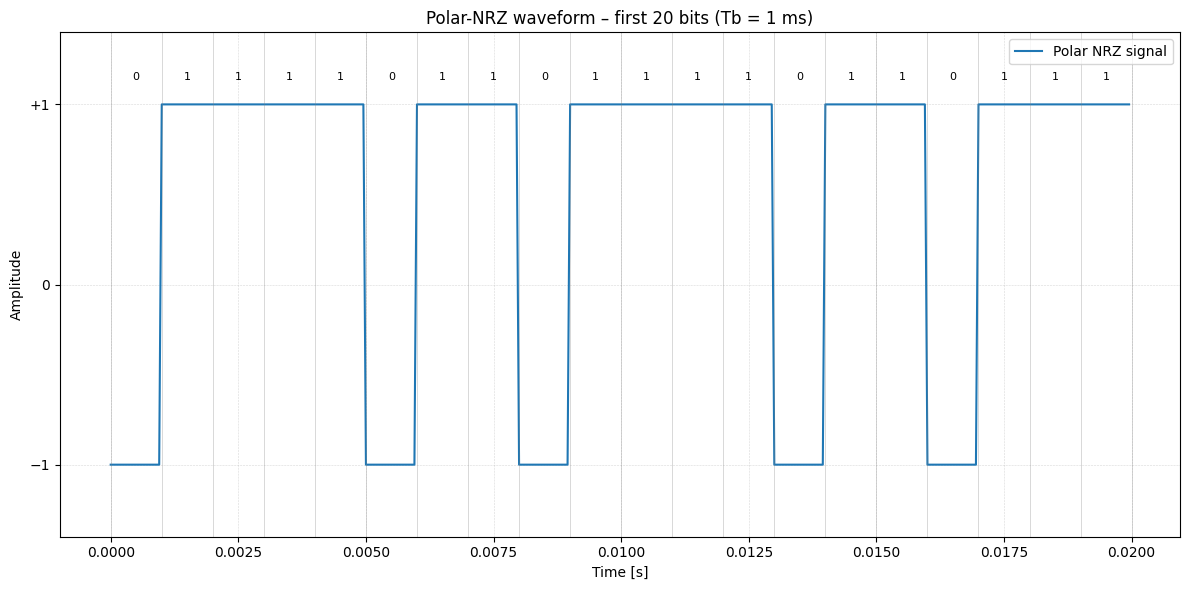

Step 4   Rendering eye diagram (showing inter-symbol interference and timing window)


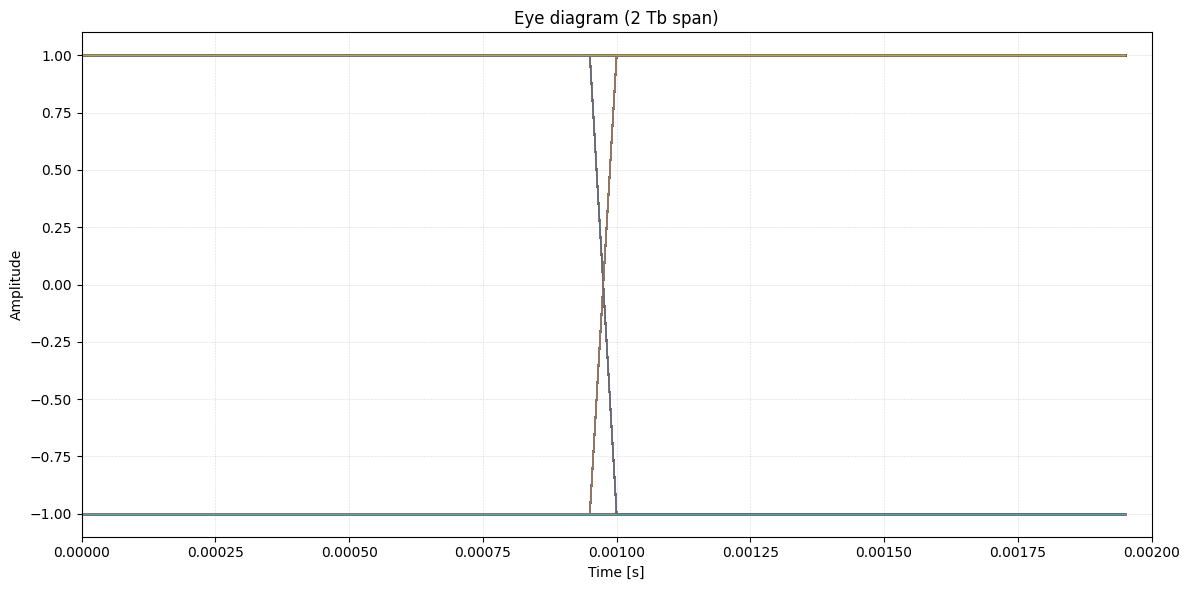

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from IPython.display import Audio, display

def PcmEncode(Signal: np.ndarray, LevelsCount: int = 256) -> np.ndarray:
    Signal         = Signal.astype(np.float64)
    MinVal, MaxVal = Signal.min(), Signal.max()
    Step           = (MaxVal - MinVal) / LevelsCount
    Indices        = np.clip(((Signal - MinVal) / Step).astype(int), 0, LevelsCount - 1)
    BitsPerSample  = int(np.log2(LevelsCount))
    Fmt            = "{0:0" + str(BitsPerSample) + "b}"
    return np.fromiter((Bit for i in Indices for Bit in Fmt.format(i)), dtype="U1")

def PolarNrzEncode(Bits: np.ndarray, Tb: float = 1e-3, Oversample: int = 20):
    N          = len(Bits)
    Fs         = Oversample / Tb
    Time       = np.linspace(0, N * Tb, N * Oversample, endpoint=False)
    PolarVals  = np.where(Bits == '1', 1.0, -1.0)
    Signal     = np.repeat(PolarVals, Oversample)
    return Time, Signal, Fs

def PlotFirstKBits(Time: np.ndarray, Signal: np.ndarray, Bits: np.ndarray,
                   K: int = 20, Tb: float = 1e-3, Oversample: int = 20):
    EndIdx = K * Oversample
    plt.figure(figsize=(12, 6))
    plt.plot(Time[:EndIdx], Signal[:EndIdx], label="Polar NRZ signal")
    plt.title(f"Polar-NRZ waveform – first {K} bits (Tb = {Tb*1e3:.0f} ms)")
    for n in range(K + 1):
        plt.axvline(n * Tb, color='gray', alpha=0.3, linewidth=0.7)
    for n, b in enumerate(Bits[:K]):
        plt.text(n * Tb + Tb / 2, 1.15, b, ha='center', va='center', fontsize=8)
    plt.yticks([-1, 0, 1], labels=["−1", "0", "+1"])
    plt.ylim([-1.4, 1.4])
    plt.xlabel("Time [s]")
    plt.ylabel("Amplitude")
    plt.grid(True, linestyle="--", linewidth=0.4, alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

def EyeDiagram(Signal: np.ndarray, Tb: float, Oversample: int, NTraces: int = 100):
    SamplesPerBit = Oversample
    Span          = 2 * SamplesPerBit
    fig, ax       = plt.subplots(figsize=(12, 6))
    StartIndices  = np.arange(0, len(Signal) - Span, SamplesPerBit)
    Rng           = np.random.default_rng(2022484)
    Sel           = Rng.choice(StartIndices, size=min(NTraces, len(StartIndices)), replace=False)
    for Idx in Sel:
        SegT = np.linspace(0, 2 * Tb, Span, endpoint=False)
        ax.plot(SegT, Signal[Idx:Idx + Span], linewidth=0.8, alpha=0.7)
    ax.set_title("Eye diagram (2 Tb span)")
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Amplitude")
    ax.set_xlim(0, 2 * Tb)
    ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.5)
    plt.tight_layout()
    plt.show()

AudioFile  = r"X:\Projects\PCS\Assignment 2\2022484_Shreyansh Seth.wav"
FsAudio, AudioData = wavfile.read(AudioFile)
if AudioData.ndim > 1:
    AudioData = AudioData[:, 0]

print(f"Audio loaded successfully => duration = {len(AudioData) / FsAudio:.2f} s | sampling rate = {FsAudio} Hz")

display(Audio(AudioData, rate=FsAudio))

Bits = PcmEncode(AudioData, LevelsCount=256)
print(f"Step 1   PCM encoding complete => generated bit-stream of length {len(Bits):,} bits")

Tb         = 1e-3
Oversample = 20
Time, Signal, FsLine = PolarNrzEncode(Bits, Tb, Oversample)
print(f"Step 2   Polar-NRZ line coding done => line-code sampling rate = {FsLine/1e3:.1f} kHz "
      f"({Oversample} samples per bit)")

print("Step 3   Displaying first 20 bits of the line-coded waveform")
PlotFirstKBits(Time, Signal, Bits, K=20, Tb=Tb, Oversample=Oversample)

print("Step 4   Rendering eye diagram (showing inter-symbol interference and timing window)")
EyeDiagram(Signal, Tb, Oversample, NTraces=1000)

# Report on Line Coding and Eye Diagram (Problem 3)

---

## 1. Introduction

The objectives of this exercise are:

1. Take a PCM-encoded bitstream from a recorded audio signal.  
2. Apply Polar-NRZ line coding using rectangular pulses.  
3. Show the first 20 bits of the coded waveform.  
4. Generate an eye diagram spanning two bit-periods to evaluate timing margins and intersymbol interference.

---

## 2. Methodology

1. **Audio acquisition & PCM encoding**  
   - A 7.36 s audio clip was recorded at 48 kHz and converted to mono.  
   - Uniform PCM quantization into 256 levels produced a bitstream of length 2 826 240 bits.

2. **Polar-NRZ line coding**  
   - “1” → +1 V, “0” → –1 V.  
   - Oversampling: 20 samples per bit → line-code sampling rate of 20 kHz (bit duration 1 ms).

3. **Waveform plotting**  
   - Plot the first 20 bits over time.  
   - Mark each bit boundary and annotate each bit value above its pulse.

4. **Eye diagram**  
   - Extract 1000 random 2-bit-period segments (2 ms each), aligned to bit boundaries.  
   - Overlay all segments to form the eye diagram.

---

## 3. Results

### Figure 1. Polar-NRZ waveform – first 20 bits (Tb = 1 ms)

- Rectangular pulses at ±1 V.  
- Flat plateaus with 20 samples per bit and instantaneous transitions at boundaries.

### Figure 2. Eye diagram (2 Tb span)

- Two horizontal levels at +1 V and –1 V.  
- Diagonal transition lines at the bit-boundary time.

---

## 4. Discussion

- **Eye opening:**  
  Full vertical opening of 2 V and full horizontal width of 1 ms at the sampling instant indicate no intersymbol interference and maximum noise margin.

- **Ideal sampling point:**  
  Mid-bit (0.5 ms after each transition) is the best decision instant, where the eye is widest.

- **Transition region:**  
  The only overlap (eye closure) occurs exactly at the bit boundary. Within the decision window the eye is completely open.

- **Practical considerations:**  
  In real channels, filtering, dispersion, and noise will partially close the eye. Eye-diagram measurements guide:
  1. Timing recovery  
  2. Equalizer design  
  3. Noise and jitter tolerance

---

## 5. Conclusion

1. Polar-NRZ coding was implemented correctly.  
2. The eye diagram confirms an ideal, distortion-free link with perfect timing.  
3. In non-ideal conditions, the eye diagram quantifies intersymbol interference and helps optimize the system.
